# Shovel 2D Cartesian Control Scratchpad
Control a single shovel link as a 2D Cartesian robot with two prismatic joints (X, Y) and one revolute joint (orientation)

## Section 1: Import Required Libraries

In [1]:
import numpy as np
from numpy.random import seed
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time as t

# Import the shovel controller
from shovel_controller import ShovelController, initialize_simulation, load_shovel, scatter_pebbles
from shovel_env import ShovelEnvironment

# seed random number generator
seed(42)


## Section 2: Initialize Simulation and Load Models


In [2]:
physics_env = ShovelEnvironment(working_area_bounds={'x_min': 0.1, 'x_max': 0.6, 'y_min': -0.25, 'y_max': 0.25}, gui=True)
physics_client = physics_env.initialize_environment()

# Load the shovel robot
robot_id = physics_env.robot_id
print(f"✓ Shovel loaded: robotId = {robot_id}")

# Optionally scatter pebbles in the workspace
# pebble_ids = scatter_pebbles(num_pebbles=500, min_pos=[0.1, -0.5, 0], max_pos=[1.5, 0.5, 0])
pebble_ids = physics_env.load_pebbles(num_pebbles=100, min_pos=[0.1, -0.25, 0], max_pos=[0.6, 0.25, 0])
print(f"✓ Scattered {len(pebble_ids)} pebbles in workspace area")

# Create the controller
controller = physics_env.controller
print(f"✓ ShovelController initialized")

✓ Shovel loaded: robotId = 1
✓ Scattered 97 pebbles in workspace area
✓ ShovelController initialized


## Section 3: View Robot Configuration


In [3]:
import pybullet as p

# Display robot joint information
controller.print_joint_info()
print("\n" + "="*80)
controller.print_joint_limits()

# DEBUG: Check maximum joint forces
print("\n" + "="*80)
print("DEBUG - Joint Information from URDF:")
for i in range(p.getNumJoints(robot_id)):
    info = p.getJointInfo(robot_id, i)
    print(f"\nJoint {i}:")
    print(f"  Max Force: {info[10]}")
    print(f"  Max Velocity: {info[11]}")



Total joints: 3

Joint Information:
--------------------------------------------------------------------------------
Joint 0: base_L1_joint        - Type: PRISMATIC 
Joint 1: L1_L2_joint          - Type: PRISMATIC 
Joint 2: L2_EE_joint          - Type: REVOLUTE  

Prismatic joints (indices): [0, 1]
Revolute joints (indices): [2]
Fixed joints (indices): []

2D Cartesian Control Configuration:
  X motion joint: 0 - base_L1_joint
  Y motion joint: 1 - L1_L2_joint
  Theta joint: 2 - L2_EE_joint

Joint Limits:
--------------------------------------------------------------------------------
Joint 0 (base_L1_joint):
  Limits: [-10.000, 10.000]
  Max Force: 5000.000, Max Velocity: 0.500
Joint 1 (L1_L2_joint):
  Limits: [-10.000, 10.000]
  Max Force: 5000.000, Max Velocity: 0.500
Joint 2 (L2_EE_joint):
  Limits: [-3.142, 3.142]
  Max Force: 5000.000, Max Velocity: 0.500

DEBUG - Joint Information from URDF:

Joint 0:
  Max Force: 5000.0
  Max Velocity: 0.5

Joint 1:
  Max Force: 5000.0
  Max V

## Section 4: Test Positions and Control


In [4]:
# Define test target positions
# Format: [x (m), y (m), theta (rad)]
# test_positions = [
#     [1.0, 0.0, 0.0],          
#     [0.5, 0.5, np.pi/4],      
#     [0.0, 0.0, 0.0],          # Position 3: Origin
#     [0.5, -0.5, -np.pi/4]     
# ]
test_positions = [
    [0.6, 0.0, 0.0],          
    [0.5, 0.5, np.pi/4],      
    [0.0, 0.0, 0.0],          # Position 3: Origin
    [0.5, -0.5, -np.pi/4]     
]

print("Test Positions (x [m], y [m], theta [deg]):")
for i, pos in enumerate(test_positions):
    print(f"  Position {i+1}: x={pos[0]:.2f}m, y={pos[1]:.2f}m, theta={np.degrees(pos[2]):.1f}°")


Test Positions (x [m], y [m], theta [deg]):
  Position 1: x=0.60m, y=0.00m, theta=0.0°
  Position 2: x=0.50m, y=0.50m, theta=45.0°
  Position 3: x=0.00m, y=0.00m, theta=0.0°
  Position 4: x=0.50m, y=-0.50m, theta=-45.0°


## Section 5a: Execute Sequential Control and Visualize Trajectory


In [5]:
# # Execute movement to a target position
# target_idx = 0
# target = test_positions[target_idx]

# print(f"Moving to target position {target_idx + 1}: x={target[0]:.2f}m, y={target[1]:.2f}m, theta={np.degrees(target[2]):.1f}°\n")

# trajectory, errors, joint_velocities, target_velocities = controller.apply_cartesian_control_sequential(
#     target[0], target[1], target[2],
#     # max_force=100,
#     max_force=10,
#     max_velocity=0.01,
#     total_steps=200
# )

# # Plot results with joint velocities and target velocities
# controller.plot_trajectory_results(trajectory, errors, target, joint_velocities, target_velocities)

# print(f"\n✓ Control execution complete")

## Section 5b: Velocity Control Mode (Alternative)
Use VELOCITY_CONTROL for strict velocity constraints (joint position is still tracked but velocity is directly controlled)

Moving to target position 1 (VELOCITY_CONTROL): x=0.60m, y=0.00m, theta=0.0°

Starting velocity control to target:
  Target: X=0.6000, Y=0.0000, Theta=0.00°
  Max velocity: 0.1500 rad/s or m/s



✓ Target reached at step 1368
  Position error: 0.009975m
  Theta error: 0.0025°


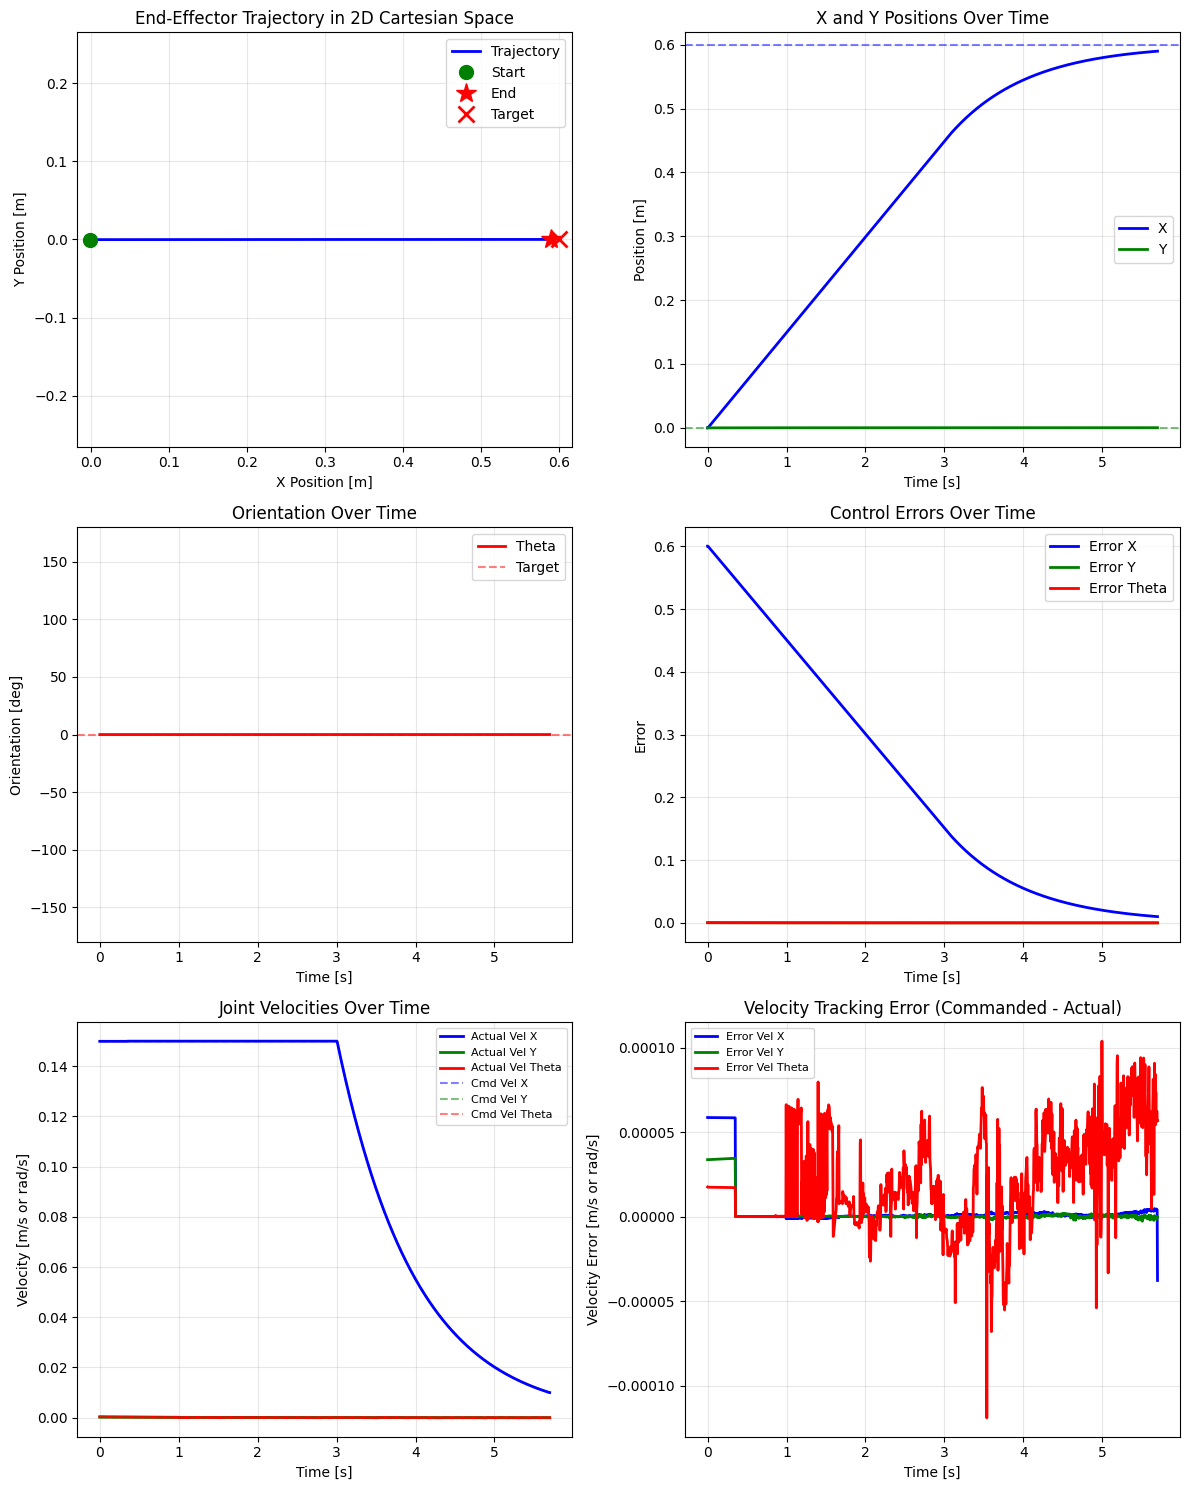


Final State:
  Position: (0.5900m, -0.0000m)
  Orientation: -0.00°
  Final Joint Velocities: X=0.0100, Y=0.0000, Theta=-0.0000
  Final Commanded Velocities: X=0.0100, Y=0.0000, Theta=0.0000
Target Position:   (0.6000m, 0.0000m, 0.00°)

✓ Velocity control execution complete


In [5]:
# Test velocity control mode (tracks position while enforcing strict velocity limits)
# target_idx = 2
target_idx = 0
target = test_positions[target_idx]

print(f"Moving to target position {target_idx + 1} (VELOCITY_CONTROL): x={target[0]:.2f}m, y={target[1]:.2f}m, theta={np.degrees(target[2]):.1f}°\n")

trajectory_vel, errors_vel, joint_velocities_vel, commanded_velocities_vel = controller.apply_cartesian_control_velocity_mode(
    target[0], target[1], target[2],
    max_velocity=0.15,
    # max_velocity=0.5,
    max_force=5000,
    # max_force=100,
    tolerance=0.01,
    max_steps=5000
)

# Step the simulation to ensure all commands are processed and results are updated
# physics_env.step()

# Plot results - shows actual vs commanded velocities
controller.plot_trajectory_results(trajectory_vel, errors_vel, target, joint_velocities_vel, commanded_velocities_vel, mode='velocity')

print(f"\n✓ Velocity control execution complete")

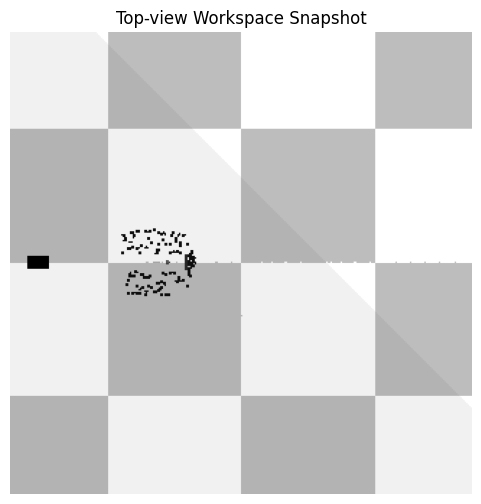

In [6]:
# Capture and display workspace top-view
top_view_gray = controller.get_top_view()

# Save to output directory
# snapshot_path = controller.save_top_view()

# Display in notebook
plt.figure(figsize=(6, 6))
plt.imshow(top_view_gray[:, :, 0], cmap='gray')
plt.title('Top-view Workspace Snapshot')
plt.axis('off')
plt.show()

# print(f"✓ Snapshot saved to: {snapshot_path.resolve()}")


In [7]:
# Cleanup when done
# Uncomment to close the simulation
# p.disconnect()
physics_env.close()

print("✓ Simulation is running. Use p.disconnect() to close when done.")

✓ Simulation is running. Use p.disconnect() to close when done.
